## 1. Import the libraries:

In [1]:
import pandas as pd
import sqlite3
from sqlalchemy import create_engine
import os
import numpy as np
from IPython.display import display, Markdown, Image


import chart_studio.plotly as py
import plotly.express as px
import plotly.graph_objects as go
import cufflinks as cf
import matplotlib.pyplot as plt
%matplotlib inline


import warnings
warnings.filterwarnings("ignore")

from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
cf.go_offline()

## 2. Connect the database:

In [2]:
db_path = "../data/ecommerce.db"
conn = sqlite3.connect(db_path)
print(f"Database connection was success!: {conn}")


Database connection was success!: <sqlite3.Connection object at 0x000002936C6E34C0>


In [3]:
# Get the list of the available tables:
all_tables= """ 
                SELECT 
                    name  
                FROM 
                    sqlite_master 
                WHERE 
                    type='table'; 
            """

tables = pd.read_sql_query(all_tables, conn)
print(f"The list of the tables:\n{tables}")

The list of the tables:
                           name
0                     customers
1                   geolocation
2                        orders
3                   order_items
4                order_payments
5                 order_reviews
6                      products
7                       sellers
8  product_category_translation


## 3. Business Queries:

### 1. Business Problem:
<hr>

In e-commerce, revenue loss is not caused solely by low demand or poor sales performance. A significant portion of lost revenue originates from orders that were successfully placed but never fulfilled due to cancellations.

Each cancelled order represents:
1. Lost revenue that was expected but never realized
2. Wasted logistics and operational effort (inventory handling, processing)
3. Poor customer experience, which can reduce trust
4. Potential long-term customer churn


Importantly, not all cancellations have the same business impact.
Cancellations in low-volume but high-value categories can be significantly more damaging than a large number of cancellations in low-priced categories.

Therefore, treating all cancellations equally may lead to misaligned priorities.
A data-driven approach is required to identify where revenue leakage is most severe and where intervention should be prioritized.

<hr>

### 2. Analytical Objective:
<hr>

The objective of this analysis is to identify product categories that contribute most to revenue leakage by evaluating:
   1. Cancellation rates (operational reliability)
   2. Absolute revenue lost due to cancellations (financial impact)
   3. Relative revenue impact compared to other categories for prioritization
    

This allows the business to distinguish between:
1. Operational inefficiencies (frequent but low-impact cancellations, cost-wise)
2. High-risk revenue segments (infrequent but expensive cancellations)
3. Low-priority noise that doesn't require immediate action


<hr> 

### 3. Hypothesis:
<hr>

Before conducting the analysis, the following hypothesis are formulated:

**Hypothesis 1:**
High-priced or logistics-heavy categories will show disproportionately high revenue loss, even if cancellation volume is low.

**Hypothesis 2:**
Some categories may have high cancellation rates but low revenue impact, indicating operational inefficiencies rather than financial risk.


<hr>

### 4. Data Mapping and Table Selection:
<hr>

The tables we will be using for this business problem:

`1. orders:` to identify the canceled orders via `order_status`

`2. order_items:` to calculate the revenues or possible revenues based on the order status

`3. products:` to map the items to the categories

`4. product_category_translation:` for readable category names


<hr>

# 1. Baseline Revenue Leakage:
<hr>

### Q. How much revenue is lost due to cancellations overall?

For this metrics, I will be considering both `price` + `freight_value` 

Check for any duplicates:

Here, `order_id` and `order_item_id` will be crucial, where, `order_id` represents an ID for one checkout
where as `order_item_id` represents the number of items in that particular checkout.

In [4]:
query = """
        WITH order_info AS 
            
            (SELECT 
                o.order_id,  
                oi.price, oi.order_item_id,
                oi.freight_value, (oi.price + oi.freight_value) AS total
            FROM   
                order_items oi   LEFT JOIN  orders o
                ON  oi.order_id = o.order_id)
                    
        
            SELECT 
                order_id, order_item_id,
                COUNT(*) AS total
            FROM 
                order_info 
            GROUP BY 
                order_id, order_item_id
            HAVING COUNT(*) > 1;
        """

duplicates = pd.read_sql_query(query, conn)
duplicates

,order_id,order_item_id,total


There is no any duplicates. A duplicate data would have falsify the revenue calculations, since there are no any duplicates, summing at the row level is safe.

###### 1.1 Calculation of the expected revenue despite the `order status`:

In [5]:
query = """ 
            WITH total_price_info AS 
                                    (SELECT 
                                        o.order_id,  oi.price, 
                                        oi.freight_value,
                                        (oi.price + oi.freight_value) AS total
                                     FROM  
                                         order_items oi   INNER JOIN  orders o
                                            ON  oi.order_id = o.order_id
                                     WHERE 
                                        oi.price  IS NOT NULL AND 
                                        oi.freight_value IS NOT NULL)
            
                                    
            
            SELECT
                SUM(total) AS total_expected_revenue
            FROM   
                total_price_info; 

            """


total_expected_revenue = pd.read_sql_query(query, conn)
total_expected_revenue_in_million = np.round(total_expected_revenue.iloc[:, 0][0]/1000000, 2)

In [6]:
print(f"The total expected revenue was: {total_expected_revenue_in_million} million.")

The total expected revenue was: 15.84 million.


##### 1.2 Calculation of  the cancelled revenue:

In [7]:
query = """ WITH canceled_orders AS 
                                    (SELECT  
                                         o.order_id, 
                                         oi.price, oi.freight_value,
                                         (oi.price + oi.freight_value) AS total,
                                         order_status
                                     FROM   
                                         order_items oi  INNER JOIN   orders o
                                         ON  oi.order_id = o.order_id
                                     WHERE  
                                         o.order_status = 'canceled'
                                         AND oi.price IS NOT NULL 
                                         AND oi.freight_value IS NOT NULL)
            
            SELECT 
                SUM(total) AS cancelled_revenue 
            FROM 
                canceled_orders;           
       
       """

cancelled_revenue = pd.read_sql_query(query, conn)
cancelled_revenue_in_millions = np.round(cancelled_revenue.iloc[:, 0][0]/1000000, 2)

In [8]:
print(f"A total of {cancelled_revenue_in_millions} million was the lost revenue from the orders cancelled.")

A total of 0.11 million was the lost revenue from the orders cancelled.


##### 1.3 Revenue Leakage Percentage:

In [9]:
revenue_leakage_percentage= (cancelled_revenue.iloc[:, 0][0] / total_expected_revenue.iloc[:, 0][0]) * 100
print(f"The total revenue leakge is: {revenue_leakage_percentage:.2f} %.")

The total revenue leakge is: 0.67 %.


##### 1.4 Actual Revenue:

Here, I will only consider the orders which has `order_status=delivered`

In [10]:
query = """
        WITH orders_completed AS 
                                (SELECT
                                    o.order_id, oi.price, oi.freight_value,
                                    (oi.price + oi.freight_value) AS total,
                                    order_status
                                  FROM
                                      order_items oi  INNER JOIN  orders o
                                      ON  oi.order_id = o.order_id
                                  WHERE
                                      order_status = 'delivered')
        
        SELECT
            SUM(total) AS total_revenue
        FROM
            orders_completed ;
        """

revenue_from_orders_completed = pd.read_sql_query(query, conn)


In [11]:
rev_frm_comp_orders_in_millions = np.round(revenue_from_orders_completed.iloc[:, 0][0]/1000000, 2)

In [12]:
print(f"The total revenue from orders completed is: {rev_frm_comp_orders_in_millions:.2f} million.")

The total revenue from orders completed is: 15.42 million.


##### 1.5 Headline Metrics:

In [13]:
all_monetary_values = {'Expected Revenue' : total_expected_revenue_in_million,
                      'Actual Revenue (completed orders)': rev_frm_comp_orders_in_millions,
                      'Cancelled Revenue': cancelled_revenue_in_millions}

all_monetary_values_df = pd.DataFrame.from_dict(all_monetary_values,
                                               orient='index',
                                               columns=['Amount (million)']
                                               ).reset_index().rename(columns={'index':'Metrics'})

In [14]:
all_monetary_values_df

,Metrics,Amount (million)
0,Expected Revenue,15.84
1,Actual Revenue (completed orders),15.42
2,Cancelled Revenue,0.11


##### 1.6 Breakdown of  Orders:

In [15]:
q = """
    SELECT
        order_status, 
        COUNT(*) AS total_orders 
    FROM
       orders 
    GROUP BY
        order_status 
    ORDER BY
        total_orders DESC;"""

order_status_dist = pd.read_sql_query(q, conn)
order_status_dist

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


##### 1.7 Breakdown of Cancelled Orders:

In [16]:
query = """
        SELECT
            COUNT(*) AS canceled_orders_without_items
        FROM
            orders o
            LEFT JOIN order_items oi
                ON o.order_id = oi.order_id
        WHERE
            o.order_status = 'canceled'
                AND oi.order_id IS NULL;
        """


without_items = pd.read_sql_query(query, conn)
without_items_val = without_items.iloc[:, 0][0]

query = """
        SELECT
            COUNT(DISTINCT o.order_id) AS canceled_orders_with_items
        FROM
            orders o
                JOIN order_items oi
                    ON o.order_id = oi.order_id
        WHERE
            o.order_status = 'canceled'
                AND oi.order_id IS NOT NULL;
        """

with_items = pd.read_sql_query(query, conn)
with_items_value = with_items.iloc[:, 0][0]

total_canceled_orders = without_items_val + with_items_value

In [17]:
cancl_ord_brk_df = pd.DataFrame.from_dict({
    'Canceled orders without items': without_items_val,
    'Canceled orders with items': with_items_value}, orient='index',
     columns=['Count']).reset_index().rename(columns={'index': 'Category'})

cancl_ord_brk_df

,Category,Count
0,Canceled orders without items,164
1,Canceled orders with items,461


In [18]:
display(Markdown(""" ## Baseline Revenue Leakage Analysis (Order-Level Reconciliation):\n"""))
display(Markdown("""### Headline Metrics: 
All monetary values include the product `(price + freight)` value."""))

display(all_monetary_values_df)
display(Markdown(f"""
**Interpretation:**

- **Expected Revenue:** represents the total potential revenue if all the orders were
fulfilled. 
- **Actual revenue:** reflects only completed orders.
- **Cancelled revenue:** reflects the total amount the company lost because the orders got cancelled. <br>

Considering all these metrics, the company has a revenue leakge of: **{revenue_leakage_percentage:.3f}**%

### Revenue Reconciliation Across Order States:
At first glance, 
the difference between `Expected Revenue`: **{total_expected_revenue_in_million} million** - 
`Actual Revenue (completed orders)`: **{rev_frm_comp_orders_in_millions} million** ≠ `Cancelled Revenue`: 
**{cancelled_revenue_in_millions} million**.

This discrepancy exists because not all the `orders` are in a final state.

**Order Status Distribution:**"""))        
display(order_status_dist)
display(Markdown(f""" 
- Only **delivered** orders generate the realized revenue.
- **Canceled** orders which contain the items contribute to the revenue leakage.

### Orders Vs Order Items: 
Revenue is generated at the item level, not at the order record level.

#### Data Grain Clarification:
- `Orders` table:
    - One row = one checkout attempt
    - The records can exist **with or without items**.
    
- `Order Items` table:
    - One row = one purchasable item
    - Each record represents actual revenue exposure
    
#### Breakdown of Canceled Orders:"""))

display(cancl_ord_brk_df)


display(Markdown(f"""

Total cancelled orders: Cancelled Orders without items **({without_items_val})** + Canceled orders with items **({with_items_value})** 
= Total Cancelled Orders **({total_canceled_orders})**


#### Use of `order_items` for Revenue Leakage Analysis:
Revenue leakage must be calculated at the item level, because revenue is generated per item, not per order record.

Using `order_items` ensures:
- No overcounting of empty orders.
- Accurate attribution of lost revenue.
- Correct handling of multi-item orders

This methodological choice is intentional and required for reliable revenue analysis.

### Key Takeaway:
- **{revenue_leakage_percentage:.3f}%** of total potential revenue is lost due to cancellations.
- Not all canceled orders imply lost revenue.
- **{without_items_val}** orders were canceled before item confirmation (no revenue impact).
- **{with_items_value}** orders contained items (only these contribute to revenue leakage).
- `Item-level` analysis prevents misleading conclusions.
- This reconciliation validates the integrity of the revenue leakage calculation.

"""))

 ## Baseline Revenue Leakage Analysis (Order-Level Reconciliation):


### Headline Metrics: 
All monetary values include the product `(price + freight)` value.

,Metrics,Amount (million)
0,Expected Revenue,15.84
1,Actual Revenue (completed orders),15.42
2,Cancelled Revenue,0.11



**Interpretation:**

- **Expected Revenue:** represents the total potential revenue if all the orders were
fulfilled. 
- **Actual revenue:** reflects only completed orders.
- **Cancelled revenue:** reflects the total amount the company lost because the orders got cancelled. <br>

Considering all these metrics, the company has a revenue leakge of: **0.668**%

### Revenue Reconciliation Across Order States:
At first glance, 
the difference between `Expected Revenue`: **15.84 million** - 
`Actual Revenue (completed orders)`: **15.42 million** ≠ `Cancelled Revenue`: 
**0.11 million**.

This discrepancy exists because not all the `orders` are in a final state.

**Order Status Distribution:**

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


 
- Only **delivered** orders generate the realized revenue.
- **Canceled** orders which contain the items contribute to the revenue leakage.

### Orders Vs Order Items: 
Revenue is generated at the item level, not at the order record level.

#### Data Grain Clarification:
- `Orders` table:
    - One row = one checkout attempt
    - The records can exist **with or without items**.

- `Order Items` table:
    - One row = one purchasable item
    - Each record represents actual revenue exposure

#### Breakdown of Canceled Orders:

,Category,Count
0,Canceled orders without items,164
1,Canceled orders with items,461




Total cancelled orders: Cancelled Orders without items **(164)** + Canceled orders with items **(461)** 
= Total Cancelled Orders **(625)**


#### Use of `order_items` for Revenue Leakage Analysis:
Revenue leakage must be calculated at the item level, because revenue is generated per item, not per order record.

Using `order_items` ensures:
- No overcounting of empty orders.
- Accurate attribution of lost revenue.
- Correct handling of multi-item orders

This methodological choice is intentional and required for reliable revenue analysis.

### Key Takeaway:
- **0.668%** of total potential revenue is lost due to cancellations.
- Not all canceled orders imply lost revenue.
- **164** orders were canceled before item confirmation (no revenue impact).
- **461** orders contained items (only these contribute to revenue leakage).
- `Item-level` analysis prevents misleading conclusions.
- This reconciliation validates the integrity of the revenue leakage calculation.



# 2. Category Level Revenue Leakage:

In [19]:
display(Markdown(f"""### Q. Which product categories contribute the most to revenue loss due to order cancellations?
- Although, the revenue leakage was **{revenue_leakage_percentage:.3f}%** which is low but 
the number could have been higher and its a good idea to drill down based on the product category and compare 
those categories based on the cancellations."""))

### Q. Which product categories contribute the most to revenue loss due to order cancellations?
- Although, the revenue leakage was **0.668%** which is low but 
the number could have been higher and its a good idea to drill down based on the product category and compare 
those categories based on the cancellations.

In [20]:
query = """
       
       WITH order_prod_info_table AS (                   
                                    SELECT
                                       o.order_id, oi.order_item_id, 
                                       p.product_category_name,
                                       o.order_status,
                                       p.product_id,
                                       oi.price, oi.freight_value,
                                       (oi.price + oi.freight_value) AS total_amount
                                    FROM
                                        order_items oi LEFT JOIN orders o
                                            ON oi.order_id = o.order_id
                                        LEFT JOIN products p 
                                            ON oi.product_id = p.product_id
                                    WHERE
                                        o.order_status = 'canceled'
                                    ),
                                        
                                
       
           orders_cncl_w_prod_cat_name AS ( 
                                        SELECT
                                           product_category_name_english, total_amount,
                                           order_status
                                        FROM
                                            order_prod_info_table AS opinf 
                                            LEFT JOIN product_category_translation AS pct
                                                ON opinf.product_category_name = pct.product_category_name
                                            ),
                                                
                                                
           lost_amount_per_category AS (
                                       SELECT
                                            COALESCE(product_category_name_english, 'Unknown') AS product_category,
                                            SUM(total_amount) AS total_amount
                                       FROM 
                                            orders_cncl_w_prod_cat_name
                                       GROUP BY
                                            product_category_name_english
                                        )

        SELECT
            product_category,
            total_amount,
            ROUND((total_amount / (SELECT SUM(total_amount) FROM lost_amount_per_category)) * 100, 3) AS revenue_leak_percentage   
        FROM
            lost_amount_per_category
        ORDER BY
            total_amount DESC;                                                                            
       """
cancellation_by_category = pd.read_sql_query(query, conn)
max_amount = cancellation_by_category[cancellation_by_category['total_amount'] == cancellation_by_category['total_amount'].max()]
min_amount = cancellation_by_category[cancellation_by_category['total_amount'] == cancellation_by_category['total_amount'].min()]
top_10 = cancellation_by_category.head(10)

 ## Category Level Revenue Leakage Analysis:
All monetary values include `product + freight` value.

The table below shows the total amount and the revenue leakage in percentage
that were lost by the order cancellations per the product category:

,product_category,total_amount,revenue_leak_percentage
0,cool_stuff,15153.48,14.311
1,sports_leisure,9411.85,8.889
2,computers_accessories,8330.82,7.868
3,watches_gifts,7249.14,6.846
4,auto,6731.72,6.358
5,housewares,6362.63,6.009
6,garden_tools,4694.01,4.433
7,toys,4589.26,4.334
8,musical_instruments,4116.05,3.887
9,health_beauty,3582.29,3.383


Where **the maximum amount along with the revenue leakage in percentage was**: 

,product_category,total_amount,revenue_leak_percentage
0,cool_stuff,15153.48,14.311


And **the minimum amount along with the revenue leakage in percentage** was: 

,product_category,total_amount,revenue_leak_percentage
46,christmas_supplies,20.93,0.02


<br>

The chart below shows the **top 10 product catgories based on their contribution for the highest
                 revenue leakge:**

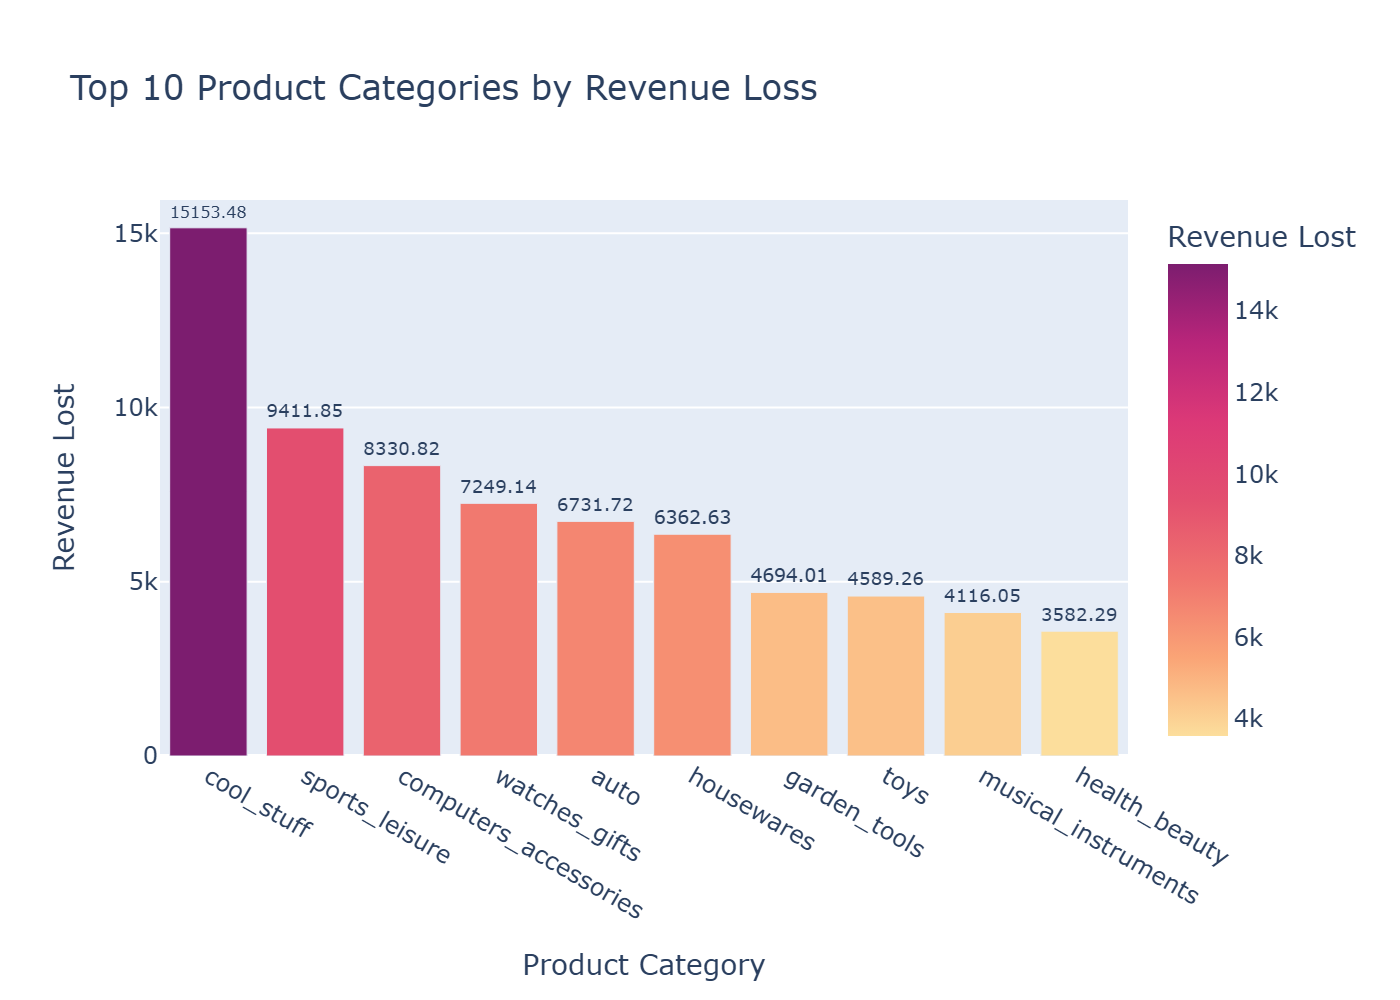


### Summary:
- Focusing on product categories contributing the most to revenue leakage can help the company **reduce losses significantly**.
- Categories with high cancellations, like those in the top 10 chart, are **priority areas for intervention** (e.g., improving fulfillment, reviewing high-value items, or adjusting policies).
- Continuous monitoring at the category level ensures **proactive revenue protection**.


In [21]:
display(Markdown(f""" ## Category Level Revenue Leakage Analysis:
All monetary values include `product + freight` value.

The table below shows the total amount and the revenue leakage in percentage
that were lost by the order cancellations per the product category:"""))

display(cancellation_by_category)

display(Markdown("Where **the maximum amount along with the revenue leakage in percentage was**: "))
display(max_amount)

display(Markdown("And **the minimum amount along with the revenue leakage in percentage** was: "))
display(min_amount)
display(Markdown("<br>"))
display(Markdown("""The chart below shows the **top 10 product catgories based on their contribution for the highest
                 revenue leakge:**"""))

fig = px.bar(data_frame=top_10, 
                     x='product_category', 
                     y='total_amount', 
                     title='Top 10 Product Categories by Revenue Loss',
                     labels={'product_category': 'Product Category',
                             'total_amount': 'Revenue Lost'},
                     text= 'total_amount',
                     color = 'total_amount',
                     color_continuous_scale = 'sunsetdark')

fig.update_traces(
    texttemplate = "%{text:.2f}",
    textposition = "outside"
)

display(fig)
fig.write_image("../plots/Top_10_Product_Categories_by_Revenue_Loss.png", scale=2)
display(Image(filename="../plots/Top_10_Product_Categories_by_Revenue_Loss.png"))

display(Markdown("""
### Summary:
- Focusing on product categories contributing the most to revenue leakage can help the company **reduce losses significantly**.
- Categories with high cancellations, like those in the top 10 chart, are **priority areas for intervention** (e.g., improving fulfillment, reviewing high-value items, or adjusting policies).
- Continuous monitoring at the category level ensures **proactive revenue protection**.
"""))

# 3. Category Level Comparison (Volume vs Revenue)

### 3.1 Finding the total number of cancellations by product category:

In [22]:
query  = """
            WITH order_prod_info_table AS (                   
                                            SELECT
                                               o.order_id, oi.order_item_id, 
                                               p.product_category_name,
                                               o.order_status,
                                               p.product_id,
                                               oi.price, oi.freight_value,
                                               (oi.price + oi.freight_value) AS total_amount
                                            FROM
                                                order_items oi LEFT JOIN orders o
                                                    ON oi.order_id = o.order_id
                                                LEFT JOIN products p 
                                                    ON oi.product_id = p.product_id
                                            WHERE
                                                o.order_status = 'canceled'
                                            ),
                              
                                
            orders_cncl_w_prod_cat_name AS ( 
                                             SELECT
                                                order_id, order_item_id,
                                                COALESCE(product_category_name_english, 'Unknown') AS product_category, 
                                                total_amount,
                                                order_status
                                              FROM
                                                 order_prod_info_table AS opinf 
                                                 LEFT JOIN product_category_translation AS pct
                                                     ON opinf.product_category_name = pct.product_category_name
                                            )
                                            
           SELECT
               product_category,
               COUNT(order_id) AS total_n_orders
           FROM
               orders_cncl_w_prod_cat_name
           GROUP BY
               product_category
           ORDER BY
               total_n_orders DESC;
"""

cncl_count_per_category = pd.read_sql_query(query, conn)

In [23]:
cncl_count_per_category.head(2)

,product_category,total_n_orders
0,sports_leisure,51
1,housewares,49


In [24]:
cancellation_by_category_cpy = cancellation_by_category.copy()

In [25]:
cancellation_by_category_cpy.head(2)

,product_category,total_amount,revenue_leak_percentage
0,cool_stuff,15153.48,14.311
1,sports_leisure,9411.85,8.889


### 3.2 Joining the two DFs for the required information of cancellation counts and amounts per category:

In [26]:
cancellation_by_category_cpy.head(2)

,product_category,total_amount,revenue_leak_percentage
0,cool_stuff,15153.48,14.311
1,sports_leisure,9411.85,8.889


In [27]:
cncl_count_per_category.head(2)

,product_category,total_n_orders
0,sports_leisure,51
1,housewares,49


In [28]:
cncl_count_and_amount = pd.merge(cancellation_by_category_cpy,
                                cncl_count_per_category,
                                on='product_category',
                                how='inner')

In [29]:
cncl_count_and_amount.head(2)

,product_category,total_amount,revenue_leak_percentage,total_n_orders
0,cool_stuff,15153.48,14.311,16
1,sports_leisure,9411.85,8.889,51



## Category Level Comparison Analysis (Canceled Volume vs Revenue Loss): 

To further understand the drivers of revenue leakage, a category-level comparison was conducted
between the **number of cancelled orders** and the **total revenue lost** per product category.

The scatter plot below visualizes this relationship:
- Each point represents a product category
- The x-axis shows the number of cancelled orders
- The y-axis shows the total revenue lost
- Color intensity (red scale) represents the magnitude of revenue loss


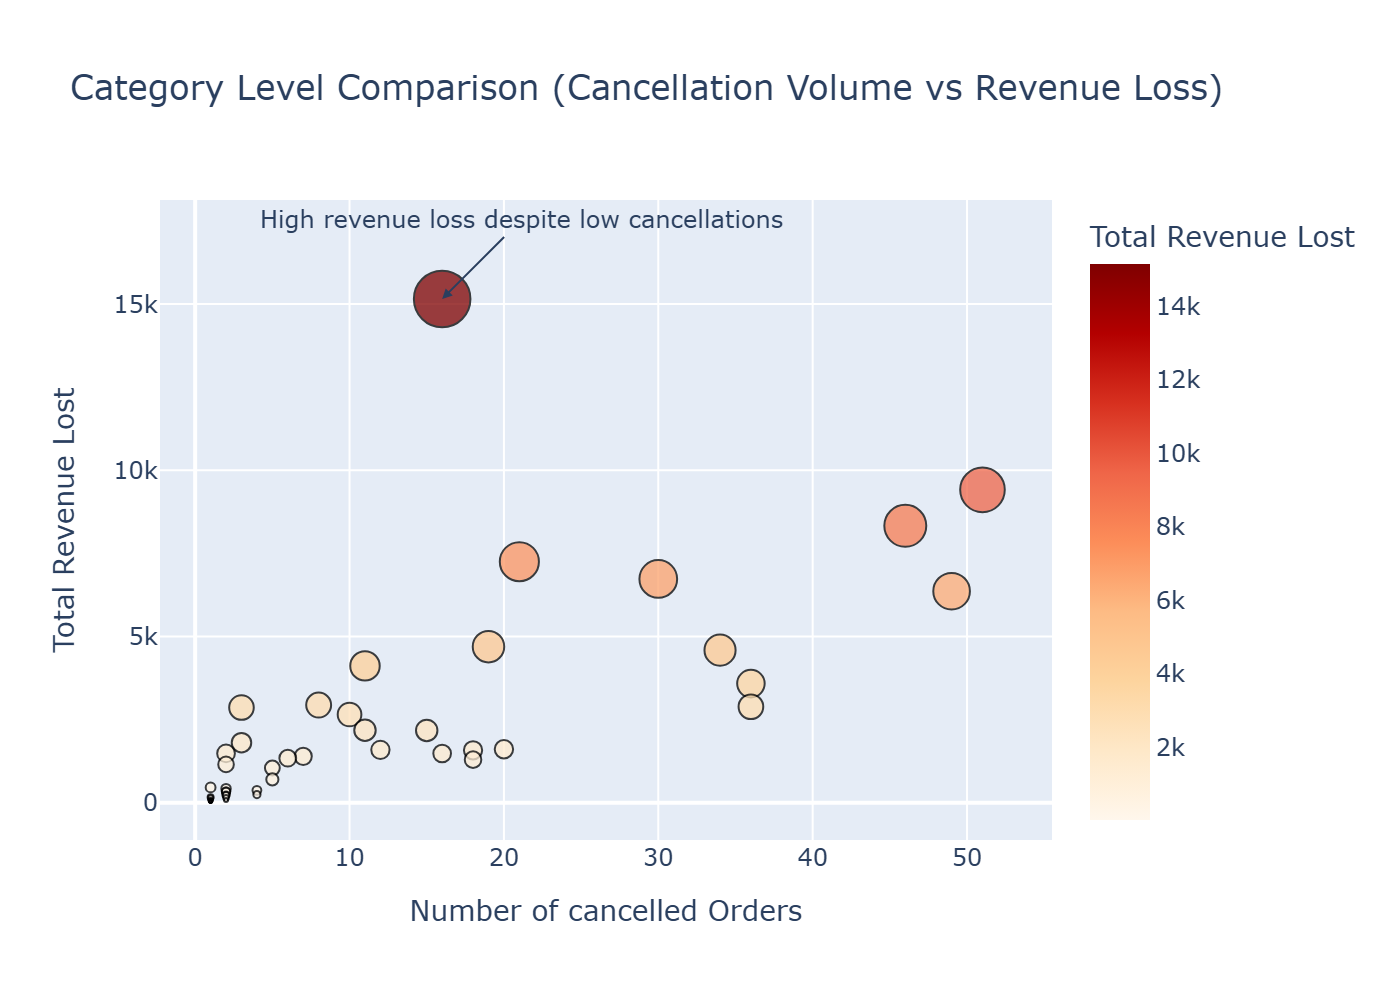


## Hypothesis Evaluation:

**Hypothesis 1:**  
*High-priced or logistics-heavy categories will show disproportionately high revenue loss, even if cancellation volume is low.*

**Supported:**  
- The visualization reveals at least one category with a relatively **low number of cancellations**
but **exceptionally high revenue loss**, indicating that high item value or logistics costs
can amplify financial impact even when cancellation volume is moderate.

---

**Hypothesis 2:**  
*Some categories may have high cancellation rates but low revenue impact, indicating operational inefficiencies rather than financial risk.*

**Supported:**  
- Several categories follow a near-linear relationship where higher cancellation volume
results in proportionally higher revenue loss. However, some categories exhibit
**high cancellation counts with comparatively lower revenue loss**, suggesting
process inefficiencies rather than major financial exposure.


There was just one outlier or a product category that is marked in the scatter plot above, where the number of cancellations
was low but the financial impact it had was high compared to all the products displayed below:


,product_category,total_amount,revenue_leak_percentage,total_n_orders
0,cool_stuff,15153.48,14.311,16



## Key Takeaways:

- Revenue leakage is **not solely driven by cancellation volume**
- Certain categories pose **higher financial risk per cancellation**
- Category-level analysis enables **prioritized intervention**:
  - High revenue loss categories → pricing, logistics, supplier review
  - High cancellation volume but low loss → operational and process improvements

This analysis highlights the importance of evaluating **both frequency and financial impact**
when addressing revenue leakage.


In [31]:
display(Markdown("""
## Category Level Comparison Analysis (Canceled Volume vs Revenue Loss): 

To further understand the drivers of revenue leakage, a category-level comparison was conducted
between the **number of cancelled orders** and the **total revenue lost** per product category.

The scatter plot below visualizes this relationship:
- Each point represents a product category
- The x-axis shows the number of cancelled orders
- The y-axis shows the total revenue lost
- Color intensity (red scale) represents the magnitude of revenue loss
"""))


fig = px.scatter(data_frame=cncl_count_and_amount,
                x='total_n_orders', 
                y='total_amount', 
                size='total_amount',
                color='total_amount',
                color_continuous_scale='OrRd',
                hover_name='product_category',
                hover_data = {
                    'total_n_orders': True,
                    'total_amount': ':.2f'
                },
                title='Category Level Comparison (Cancellation Volume vs Revenue Loss)',
                labels={
                    'total_n_orders': 'Number of cancelled Orders',
                    'total_amount': 'Total Revenue Lost'
                })
fig.update_traces( hovertemplate=
                    "<b>Category:</b> %{hovertext}<br>" +
                    "<b>Cancelled Orders:</b> %{x}<br>" +
                    "<b>Revenue Lost:</b> %{y:.2f}<br>" +
                    "<extra></extra>", 
                  marker=dict(opacity=0.75, 
                  line=dict(width=1, 
                  color='black')))
fig.add_annotation(
    x=16,
    y=15153.48,
    text="High revenue loss despite low cancellations",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40
)
display(fig)
fig.write_image("../plots/High_revenue_loss_despite_low_cancellations.png", scale=2)
display(Image(filename="../plots/High_revenue_loss_despite_low_cancellations.png"))

display(Markdown(f"""
## Hypothesis Evaluation:

**Hypothesis 1:**  
*High-priced or logistics-heavy categories will show disproportionately high revenue loss, even if cancellation volume is low.*

**Supported:**  
- The visualization reveals at least one category with a relatively **low number of cancellations**
but **exceptionally high revenue loss**, indicating that high item value or logistics costs
can amplify financial impact even when cancellation volume is moderate.

---

**Hypothesis 2:**  
*Some categories may have high cancellation rates but low revenue impact, indicating operational inefficiencies rather than financial risk.*

**Supported:**  
- Several categories follow a near-linear relationship where higher cancellation volume
results in proportionally higher revenue loss. However, some categories exhibit
**high cancellation counts with comparatively lower revenue loss**, suggesting
process inefficiencies rather than major financial exposure.


There was just one outlier or a product category that is marked in the scatter plot above, where the number of cancellations
was low but the financial impact it had was high compared to all the products displayed below:
"""))
display(cncl_count_and_amount[cncl_count_and_amount['product_category'] == 'cool_stuff'])

display(Markdown("""
## Key Takeaways:

- Revenue leakage is **not solely driven by cancellation volume**
- Certain categories pose **higher financial risk per cancellation**
- Category-level analysis enables **prioritized intervention**:
  - High revenue loss categories → pricing, logistics, supplier review
  - High cancellation volume but low loss → operational and process improvements

This analysis highlights the importance of evaluating **both frequency and financial impact**
when addressing revenue leakage.
"""))
